In [1]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torchsummary import summary

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


s:\intenship\project1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Data paths ---
DATA_DIR = r'S:\intenship\project1\data'
x_train_dir = os.path.join(DATA_DIR, 'train', 'images')
y_train_dir = os.path.join(DATA_DIR, 'train', 'masks')
x_valid_dir = os.path.join(DATA_DIR, 'val', 'images')
y_valid_dir = os.path.join(DATA_DIR, 'val', 'masks')
x_test_dir  = os.path.join(DATA_DIR, 'test', 'images')
select_class_gray_values = [255]


In [3]:
def visualize(**images):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.title(name)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()

In [4]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from glob import glob
import os

def fill_mask_border(mask):
    """Fill the white ellipse border in a binary mask to create a solid region."""
    mask = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(mask)
    cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)
    return (filled_mask / 255).astype(np.float32)

class FetalHeadDataset(Dataset):
    def __init__(self, images_dir, masks_dir, class_gray_values, augmentation=None, preprocessing=None):
        self.image_paths = sorted(glob(os.path.join(images_dir, '*')))
        self.mask_paths  = sorted(glob(os.path.join(masks_dir, '*')))
        self.class_gray_values = class_gray_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, i):
        image = cv2.imread(self.image_paths[i], cv2.IMREAD_GRAYSCALE)
        mask  = cv2.imread(self.mask_paths[i],  cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {self.image_paths[i]}")
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {self.mask_paths[i]}")

        # Normalize image
        image = image.astype('float32') / 255.0

        # Fill ellipse in mask
        mask = fill_mask_border(mask)

        # Optional: filter to specific classes if needed
        if self.class_gray_values:
            mask = np.isin(mask * 255, self.class_gray_values).astype('float32')  # Recheck gray value logic
        else:
            mask = mask.astype('float32')

        image = np.expand_dims(image, -1)
        mask  = np.expand_dims(mask, -1)

        if self.augmentation:
            augmented = self.augmentation(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        if self.preprocessing:
            processed = self.preprocessing(image=image, mask=mask)
            image, mask = processed['image'], processed['mask']

        if isinstance(mask, torch.Tensor):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = mask.squeeze(-1)
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = mask.permute(2, 0, 1)
        elif isinstance(mask, np.ndarray):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = np.squeeze(mask, axis=-1)
            if mask.ndim == 2:
                mask = np.expand_dims(mask, 0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = np.transpose(mask, (2, 0, 1))
            mask = torch.from_numpy(mask).float()

        assert mask.shape == (1, 256, 256), f"Mask shape: {mask.shape}"

        if isinstance(image, torch.Tensor):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = image.squeeze(-1)
            if image.ndim == 2:
                image = image.unsqueeze(0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = image.permute(2, 0, 1)
        elif isinstance(image, np.ndarray):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = np.squeeze(image, axis=-1)
            if image.ndim == 2:
                image = np.expand_dims(image, 0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = np.transpose(image, (2, 0, 1))
            image = torch.from_numpy(image).float()

        assert image.shape == (1, 256, 256), f"Image shape: {image.shape}"

        return image, mask


In [5]:
def get_training_augmentation():
    return A.Compose([
        A.PadIfNeeded(256, 256),
        A.RandomCrop(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.15),
        A.GaussNoise(var_limit=(10.0,50.0), p=0.1),
    ])

def get_validation_augmentation():
    return A.Compose([
        A.PadIfNeeded(256,256),
        A.CenterCrop(256,256)
    ])

def get_preprocessing():
    return A.Compose([
        A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=1.0),
        ToTensorV2()
    ])

In [6]:
BATCH_SIZE = 2
NUM_WORKERS = 0

train_dataset = FetalHeadDataset(
    x_train_dir, y_train_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing()
)
val_dataset = FetalHeadDataset(
    x_valid_dir, y_valid_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing()
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)


In [7]:
%pip install torchinfo


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
import torch.nn as nn

class SegNet(nn.Module):
    def __init__(self, in_channels=1, n_classes=1):
        super(SegNet, self).__init__()

        def conv_block(in_ch, out_ch, num_convs=2, dropout=False):
            layers = []
            for _ in range(num_convs):
                layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
                layers.append(nn.BatchNorm2d(out_ch))
                layers.append(nn.ReLU(inplace=True))
                in_ch = out_ch
            if dropout:
                layers.append(nn.Dropout2d(0.3))
            return nn.Sequential(*layers)

        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2, 2, return_indices=True)

        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2, 2, return_indices=True)

        self.enc3 = conv_block(128, 256, num_convs=3, dropout=True)
        self.pool3 = nn.MaxPool2d(2, 2, return_indices=True)

        self.enc4 = conv_block(256, 512, num_convs=3, dropout=True)
        self.pool4 = nn.MaxPool2d(2, 2, return_indices=True)

        self.enc5 = conv_block(512, 512, num_convs=3, dropout=True)
        self.pool5 = nn.MaxPool2d(2, 2, return_indices=True)

        # Decoder
        self.unpool5 = nn.MaxUnpool2d(2, 2)
        self.dec5 = conv_block(512, 512, num_convs=3, dropout=True)

        self.unpool4 = nn.MaxUnpool2d(2, 2)
        self.dec4 = conv_block(512, 256, num_convs=3)

        self.unpool3 = nn.MaxUnpool2d(2, 2)
        self.dec3 = conv_block(256, 128, num_convs=3)

        self.unpool2 = nn.MaxUnpool2d(2, 2)
        self.dec2 = conv_block(128, 64)

        self.unpool1 = nn.MaxUnpool2d(2, 2)
        self.dec1 = conv_block(64, 64)

        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x); size1 = x1.size()
        x1, idx1 = self.pool1(x1)

        x2 = self.enc2(x1); size2 = x2.size()
        x2, idx2 = self.pool2(x2)

        x3 = self.enc3(x2); size3 = x3.size()
        x3, idx3 = self.pool3(x3)

        x4 = self.enc4(x3); size4 = x4.size()
        x4, idx4 = self.pool4(x4)

        x5 = self.enc5(x4); size5 = x5.size()
        x5, idx5 = self.pool5(x5)

        # Decoder
        x5d = self.unpool5(x5, idx5, output_size=size5)
        x5d = self.dec5(x5d)

        x4d = self.unpool4(x5d, idx4, output_size=size4)
        x4d = self.dec4(x4d)

        x3d = self.unpool3(x4d, idx3, output_size=size3)
        x3d = self.dec3(x3d)

        x2d = self.unpool2(x3d, idx2, output_size=size2)
        x2d = self.dec2(x2d)

        x1d = self.unpool1(x2d, idx1, output_size=size1)
        x1d = self.dec1(x1d)

        return self.final_conv(x1d)


In [9]:
from torchsummary import summary

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Initialize SegNet model
model = SegNet(in_channels=1, n_classes=1).to(DEVICE)

# Mixed precision training scaler
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# Model summary
summary(model, input_size=(1, 256, 256), batch_size=BATCH_SIZE)


Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [2, 64, 256, 256]             640
       BatchNorm2d-2          [2, 64, 256, 256]             128
              ReLU-3          [2, 64, 256, 256]               0
            Conv2d-4          [2, 64, 256, 256]          36,928
       BatchNorm2d-5          [2, 64, 256, 256]             128
              ReLU-6          [2, 64, 256, 256]               0
         MaxPool2d-7  [[-1, 64, 128, 128], [-1, 64, 128, 128]]               0
            Conv2d-8         [2, 128, 128, 128]          73,856
       BatchNorm2d-9         [2, 128, 128, 128]             256
             ReLU-10         [2, 128, 128, 128]               0
           Conv2d-11         [2, 128, 128, 128]         147,584
      BatchNorm2d-12         [2, 128, 128, 128]             256
             ReLU-13         [2, 128, 128, 128]               0
     

In [10]:
from segmentation_models_pytorch.losses import FocalLoss
import segmentation_models_pytorch as smp
import torch
import numpy as np
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)  # Needed because you use logits
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        smooth = 1.
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice + self.bce(inputs, targets)


# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5, min_lr=1e-6)

# Helper metric functions
def safe_div(numerator, denominator):
    return (numerator + 1e-7) / (denominator + 1e-7) if denominator != 0 else 0.0


In [11]:
def iou_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    union = (outputs + labels).clamp(0, 1).sum()
    return safe_div(intersection, union)

def dice_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    total = outputs.sum() + labels.sum()
    return safe_div(2 * intersection, total)

def precision_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fp = (outputs * (1 - labels)).sum()
    return safe_div(tp, tp + fp)

def recall_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fn = ((1 - outputs) * labels).sum()
    return safe_div(tp, tp + fn)

def accuracy_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    correct = (outputs == labels).float().sum()
    total = torch.numel(outputs)
    return safe_div(correct, total)

def f1_score_pytorch(outputs, labels, threshold=0.5):
    prec = precision_pytorch(outputs, labels, threshold)
    rec = recall_pytorch(outputs, labels, threshold)
    return safe_div(2 * prec * rec, prec + rec)

In [12]:
def train_epoch(loader, model, loss_fn, optimizer, device):
    model.train()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    for images, masks in tqdm(loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss_fn = DiceBCELoss()
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)

        metrics['loss'] += loss.item()
        metrics['iou'] += iou_pytorch(probs, masks)
        metrics['dice'] += dice_pytorch(probs, masks)
        metrics['precision'] += precision_pytorch(probs, masks)
        metrics['recall'] += recall_pytorch(probs, masks)
        metrics['accuracy'] += accuracy_pytorch(probs, masks)
        metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

def eval_epoch(loader, model, loss_fn, device):
    model.eval()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss_fn = DiceBCELoss()
            loss = loss_fn(logits, masks)
            probs = torch.sigmoid(logits)

            metrics['loss'] += loss.item()
            metrics['iou'] += iou_pytorch(probs, masks)
            metrics['dice'] += dice_pytorch(probs, masks)
            metrics['precision'] += precision_pytorch(probs, masks)
            metrics['recall'] += recall_pytorch(probs, masks)
            metrics['accuracy'] += accuracy_pytorch(probs, masks)
            metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

In [13]:
NUM_EPOCHS = 100
PATIENCE = 25  # stop if no improvement after 25 epochs
counter = 0

best_val_iou, best_epoch = 0, 0
best_model_path = os.path.join(DATA_DIR, 'best_model_segnet.pth')

log = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': [],
    'train_dice': [], 'val_dice': [],
    'train_precision': [], 'val_precision': [],
    'train_accuracy': [], 'val_accuracy': [],
    'train_recall': [], 'val_recall': [],
    'train_f1': [], 'val_f1': []
}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # Training
    train_metrics = train_epoch(train_loader, model, DiceBCELoss, optimizer, DEVICE)

    # Validation
    val_metrics = eval_epoch(val_loader, model, DiceBCELoss, DEVICE)

    # Scheduler step
    lr_scheduler.step(val_metrics['loss'])

    # Logging
    print(f"Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"Train IoU: {train_metrics['iou']:.4f} | Val IoU: {val_metrics['iou']:.4f}")
    print(f"Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"Train Precision: {train_metrics['precision']:.4f} | Val Precision: {val_metrics['precision']:.4f}")
    print(f"Train Accuracy: {train_metrics['accuracy']:.4f} | Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Train Recall: {train_metrics['recall']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
    print(f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")

    for key in log.keys():
        metric_name = key.split('_', 1)[1]
        if key.startswith('train_'):
            log[key].append(train_metrics[metric_name])
        else:
            log[key].append(val_metrics[metric_name])

    # Early Stopping & Save Best Model
    if val_metrics['iou'] > best_val_iou:
        best_val_iou, best_epoch = val_metrics['iou'], epoch
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best checkpoint saved at epoch {epoch+1} with Val IoU: {best_val_iou:.4f}")
        counter = 0  # reset counter if improved
    else:
        counter += 1
        print(f"⏳ No improvement for {counter} epoch(s).")

    if counter >= PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        break

# Final summary
print(f"\n🏁 Best Val IoU: {best_val_iou:.4f} at epoch {best_epoch+1}")



Epoch 1/100


100%|██████████| 401/401 [01:02<00:00,  6.38it/s]


Train Loss: 1.0843 | Val Loss: 0.5276
Train IoU: 0.5326 | Val IoU: 0.9227
Train Dice: 0.6756 | Val Dice: 0.9534
Train Precision: 0.5969 | Val Precision: 0.9438
Train Accuracy: 0.5935 | Val Accuracy: 0.9240
Train Recall: 0.8537 | Val Recall: 0.9760
Train F1: 0.6756 | Val F1: 0.9534
✅ Best checkpoint saved at epoch 1 with Val IoU: 0.9227

Epoch 2/100


100%|██████████| 401/401 [01:01<00:00,  6.53it/s]


Train Loss: 1.0272 | Val Loss: 0.4490
Train IoU: 0.5643 | Val IoU: 0.9359
Train Dice: 0.7006 | Val Dice: 0.9611
Train Precision: 0.6086 | Val Precision: 0.9413
Train Accuracy: 0.6186 | Val Accuracy: 0.9360
Train Recall: 0.9004 | Val Recall: 0.9942
Train F1: 0.7006 | Val F1: 0.9611
✅ Best checkpoint saved at epoch 2 with Val IoU: 0.9359

Epoch 3/100


...

Train Loss: 0.7711 | Val Loss: 0.6537
Train IoU: 0.7072 | Val IoU: 0.7135
Train Dice: 0.8088 | Val Dice: 0.7804
Train Precision: 0.8085 | Val Precision: 0.9648
Train Accuracy: 0.8062 | Val Accuracy: 0.7255
Train Recall: 0.8566 | Val Recall: 0.7300
Train F1: 0.8088 | Val F1: 0.7905
⏳ No improvement for 23 epoch(s).

Epoch 36/100


100%|██████████| 401/401 [01:02<00:00,  6.45it/s]


Train Loss: 0.7745 | Val Loss: 0.7097
Train IoU: 0.7089 | Val IoU: 0.6681
Train Dice: 0.8069 | Val Dice: 0.7369
Train Precision: 0.8006 | Val Precision: 0.9527
Train Accuracy: 0.8062 | Val Accuracy: 0.6821
Train Recall: 0.8621 | Val Recall: 0.6844
Train F1: 0.8069 | Val F1: 0.7623
⏳ No improvement for 24 epoch(s).

Epoch 37/100


100%|██████████| 401/401 [01:02<00:00,  6.43it/s]


Train Loss: 0.8057 | Val Loss: 0.6404
Train IoU: 0.6882 | Val IoU: 0.7263
Train Dice: 0.7877 | Val Dice: 0.7896
Train Precision: 0.7810 | Val Precision: 0.9651
Train Accuracy: 0.7977 | Val Accuracy: 0.7373
Train Recall: 0.8497 | Val Recall: 0.7460
Train F1: 0.7877 | Val F1: 0.7998
⏳ No improvement for 25 epoch(s).

🛑 Early stopping triggered at epoch 37

🏁 Best Val IoU: 0.9435 at epoch 12


In [14]:
import matplotlib.pyplot as plt
import torch

def to_numpy(x):
    """Convert tensor to numpy, handling GPU tensors."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x

def plot_training_history(log):
    metrics = [
        ("loss", "Loss"),
        ("iou", "IoU"),
        ("dice", "Dice"),
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("accuracy", "Accuracy"),
        ("f1", "F1 Score")
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 3))

    if len(metrics) == 1:
        axes = [axes]

    for ax, (key, title) in zip(axes, metrics):
        train_key = f"train_{key}"
        val_key = f"val_{key}"

        if train_key in log and val_key in log:
            train_vals = [to_numpy(v) for v in log[train_key]]
            val_vals = [to_numpy(v) for v in log[val_key]]

            ax.plot(train_vals, label=f"Train {title}", marker='o')
            ax.plot(val_vals, label=f"Val {title}", marker='o')
            ax.set_title(f"{title} over Epochs")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(title)
            ax.grid(True)
            ax.legend()

    plt.tight_layout()
    plt.show()


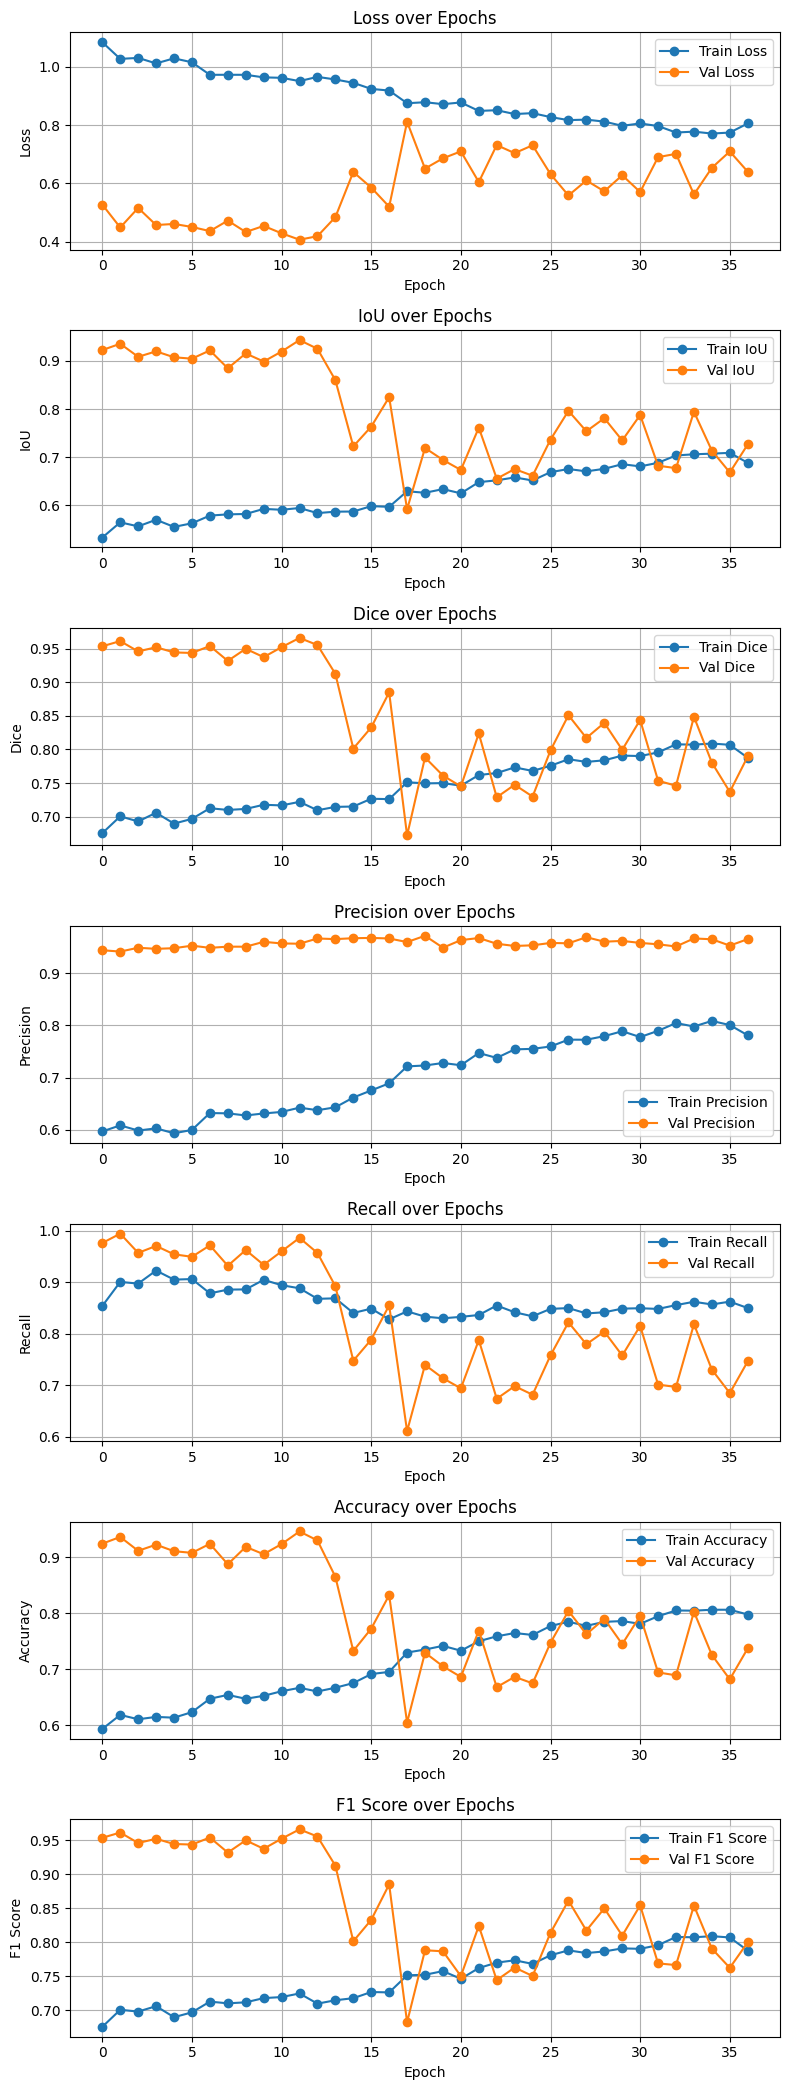

In [15]:
plot_training_history(log)


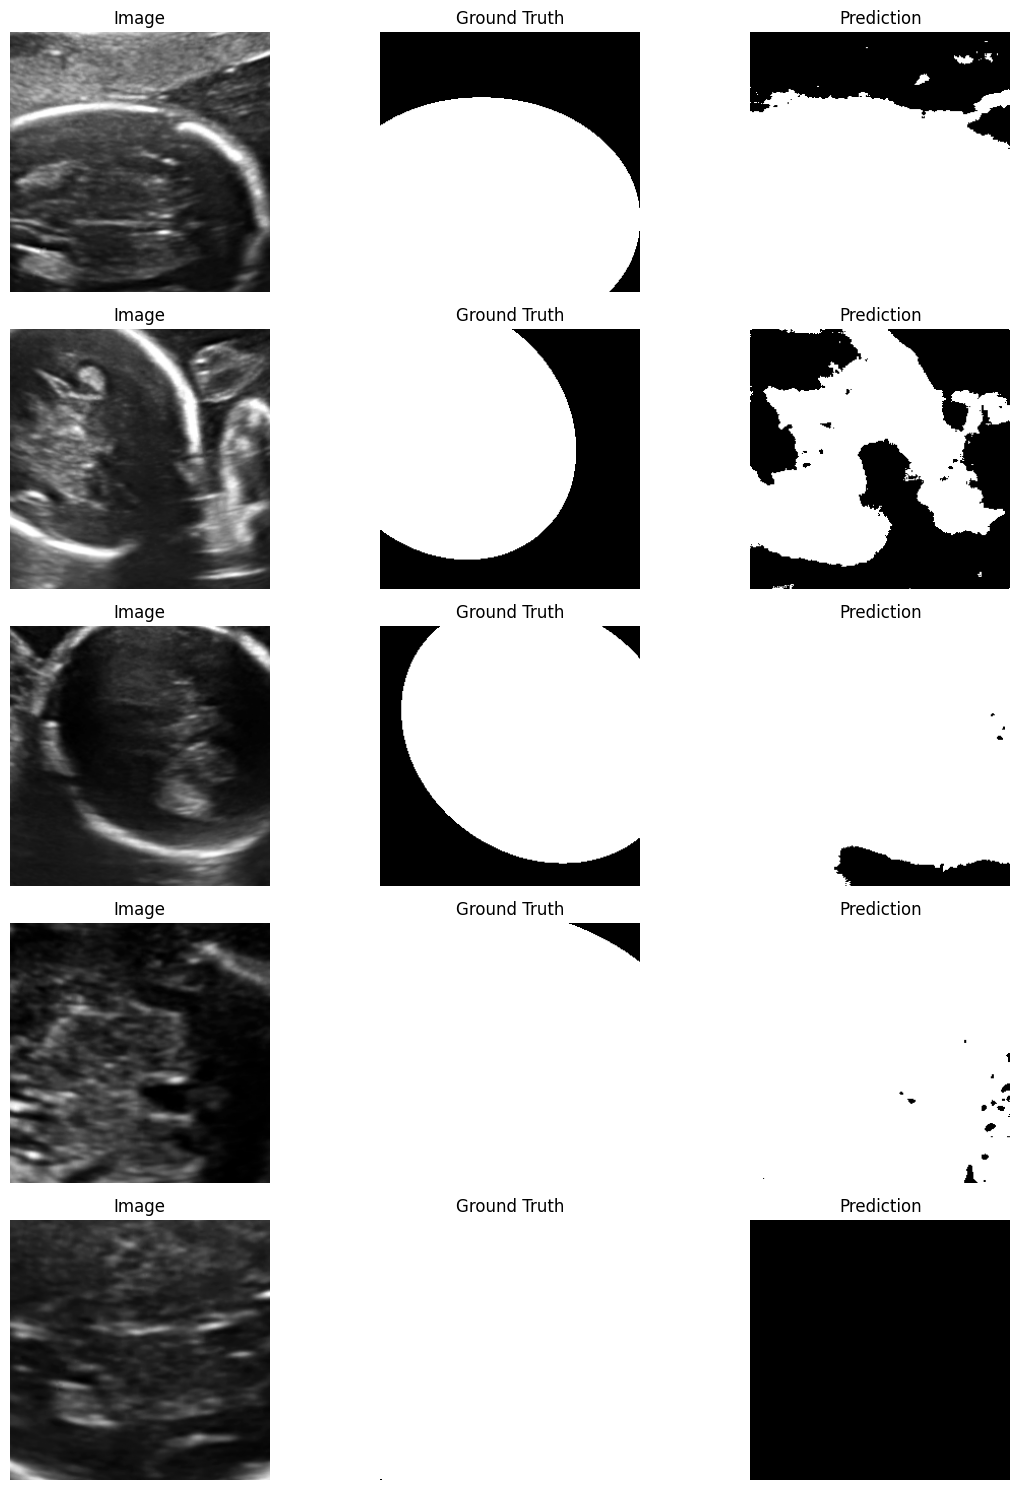

In [16]:
import matplotlib.pyplot as plt

# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# Show predictions on a few validation samples
n_samples = 5  # Number of images to visualize
fig, axs = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))

with torch.no_grad():
    for i in range(n_samples):
        # Get image and mask from validation dataset
        img, mask = val_dataset[i]
        img_input = img.unsqueeze(0).to(DEVICE)

        # Predict
        pred = torch.sigmoid(model(img_input))
        pred_mask = (pred[0, 0].cpu().numpy() > 0.5)

        # Plot
        axs[i, 0].imshow(img[0].cpu(), cmap='gray')
        axs[i, 0].set_title("Image")
        axs[i, 0].axis('off')

        axs[i, 1].imshow(mask[0].cpu(), cmap='gray')
        axs[i, 1].set_title("Ground Truth")
        axs[i, 1].axis('off')

        axs[i, 2].imshow(pred_mask, cmap='gray')
        axs[i, 2].set_title("Prediction")
        axs[i, 2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torchinfo import summary
from typing import Optional, Tuple

# ---------------------------
# Configuration (edit as needed)
# ---------------------------
DATA_DIR = r"S:\intenship\project1\data"
IMAGE_DIR = os.path.join(DATA_DIR, "test", "images")
SAVE_DIR = os.path.join(DATA_DIR, "test", "predicted_masks_segnet")
MODEL_PATH = os.path.join(DATA_DIR, "best_model_segnet.pth")  # change to your model file
GT_DIR = os.path.join(DATA_DIR, "test", "masks")  # optional: set to None if not available

BATCH_SIZE = 1
IMG_SIZE = 256
PIXEL_TO_MM = 0.13        # set according to your imaging scale
MASK_AREA_THRESH = 100    # remove small connected components smaller than this (in pixels)
PRED_THRESH = 0.6         # threshold on sigmoid output
GAMMA = 0.7               # grad-cam gamma correction
CLIP_PERCENTILE = 99.5    # clip top percentile from CAM before normalization
COLORMAP = cv2.COLORMAP_TURBO  # nicer than JET

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(SAVE_DIR, exist_ok=True)
print("Using device:", DEVICE)

# ---------------------------
# Dataset
# ---------------------------
class TestDataset(Dataset):
    def __init__(self, image_paths, img_size=IMG_SIZE):
        self.image_paths = image_paths
        self.transform = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")
        augmented = self.transform(image=img)
        return augmented['image'], path

# ---------------------------
# Mask cleaning & HC
# ---------------------------
def postprocess_binary_mask(mask: np.ndarray, area_thresh: int = MASK_AREA_THRESH) -> np.ndarray:
    # mask: 0/1 uint8
    mask_u8 = (mask.astype(np.uint8) * 255)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_closed = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel, iterations=2)
    _, mask_bin = cv2.threshold(mask_closed, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cleaned = np.zeros_like(mask_bin)
    for c in contours:
        if cv2.contourArea(c) > area_thresh:
            cv2.drawContours(cleaned, [c], -1, 255, thickness=cv2.FILLED)
    return (cleaned // 255).astype(np.uint8)

def calculate_head_circumference(mask_np: np.ndarray, pixel_to_mm: float = PIXEL_TO_MM) -> Tuple[float, Optional[np.ndarray]]:
    mask_u8 = (mask_np.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0, None
    largest = max(contours, key=cv2.contourArea)
    perimeter_px = cv2.arcLength(largest, True)
    return float(perimeter_px * pixel_to_mm), largest

# ---------------------------
# Layer selection for Grad-CAM
# ---------------------------
def find_best_gradcam_layer(module: nn.Module) -> nn.Module:
    candidates = []
    for m in module.modules():
        if isinstance(m, (nn.LayerNorm, nn.BatchNorm2d, nn.GroupNorm)):
            candidates.append(m)
    if candidates:
        return candidates[-1]
    convs = [m for m in module.modules() if isinstance(m, nn.Conv2d)]
    if convs:
        return convs[-1]
    return module

# ---------------------------
# Grad-CAM (conv & transformer friendly) with improved normalization
# ---------------------------
def normalize_cam(cam: np.ndarray, clip_percentile: float = CLIP_PERCENTILE, gamma: float = GAMMA) -> np.ndarray:
    # clip top percentile to reduce outliers, then scale to [0,1], apply gamma
    if cam.size == 0:
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    top = np.percentile(cam, clip_percentile)
    cam_clipped = np.clip(cam, a_min=None, a_max=top)
    cam_clipped -= cam_clipped.min()
    cam_clipped = cam_clipped / (cam_clipped.max() + 1e-8)
    if gamma != 1.0:
        cam_clipped = np.power(cam_clipped, gamma)
    return cam_clipped.astype(np.float32)

def apply_gradcam(model: nn.Module, input_tensor: torch.Tensor, target_layer: nn.Module, out_size: int = IMG_SIZE) -> np.ndarray:
    activations = []
    gradients = []

    def forward_hook(module, inp, out):
        activations.append(out.detach())

    def backward_hook(module, grad_in, grad_out):
        g = grad_out[0] if isinstance(grad_out, (tuple, list)) else grad_out
        gradients.append(g.detach())

    fw_handle = target_layer.register_forward_hook(forward_hook)
    try:
        bw_handle = target_layer.register_full_backward_hook(backward_hook)
    except AttributeError:
        bw_handle = target_layer.register_backward_hook(backward_hook)

    model.zero_grad()
    x = input_tensor.clone().detach().requires_grad_(True)
    out = model(x)  # forward
    score = out.mean()
    score.backward(retain_graph=False)

    if not activations or not gradients:
        fw_handle.remove()
        bw_handle.remove()
        return np.zeros((out_size, out_size), dtype=np.float32)

    act = activations[0]
    grad = gradients[0]

    # conv-style features
    if act.dim() == 4 and grad.dim() == 4:
        weights = grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * act).sum(dim=1))  # (B, H, W)
        cam_np = cam[0].cpu().numpy()
    # transformer-style tokens (B, N, C)
    elif act.dim() == 3:
        B, N, C = act.shape
        spatial = int(np.sqrt(N)) if int(np.sqrt(N))**2 == N else None
        if spatial:
            act2 = act.permute(0, 2, 1).reshape(B, C, spatial, spatial)
            grad2 = grad.permute(0, 2, 1).reshape(B, C, spatial, spatial)
            weights = grad2.mean(dim=(2, 3), keepdim=True)
            cam = F.relu((weights * act2).sum(dim=1))
            cam_np = cam[0].cpu().numpy()
        else:
            token_map = F.relu((act * grad).sum(dim=-1)).cpu().numpy()  # (B, N)
            token = token_map[0] if token_map.shape[0] == 1 else token_map[0]
            token_img = token.reshape(1, -1).astype(np.float32)
            cam_np = cv2.resize(token_img, (out_size, out_size))[0]
    else:
        cam_np = np.zeros((out_size, out_size), dtype=np.float32)

    if cam_np.shape != (out_size, out_size):
        cam_np = cv2.resize(cam_np, (out_size, out_size))

    cam_norm = normalize_cam(cam_np, clip_percentile=CLIP_PERCENTILE, gamma=GAMMA)

    fw_handle.remove()
    bw_handle.remove()
    return cam_norm

# ---------------------------
# Metrics
# ---------------------------
def compute_iou_and_dice(pred_mask: np.ndarray, gt_mask: np.ndarray) -> Tuple[float, float]:
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    iou = inter / union if union > 0 else 1.0 if not pred.any() and not gt.any() else 0.0
    dice = 2 * inter / (pred.sum() + gt.sum()) if (pred.sum() + gt.sum()) > 0 else 1.0 if not pred.any() and not gt.any() else 0.0
    return float(iou), float(dice)

def gradcam_mask_iou(cam: np.ndarray, mask: np.ndarray, cam_thresh: float = 0.4) -> float:
    cam_bin = (cam >= cam_thresh).astype(np.uint8)
    mask_bin = (mask > 0).astype(np.uint8)
    inter = np.logical_and(cam_bin, mask_bin).sum()
    union = np.logical_or(cam_bin, mask_bin).sum()
    return float(inter / union) if union > 0 else 0.0

# ---------------------------
# Build / Load Model
# ---------------------------
model = SegNet(
    in_channels=1,
    n_classes=1
).to(DEVICE)

print("Model created. Summary (attempt):")
try:
    summary(model, input_size=(BATCH_SIZE, 1, IMG_SIZE, IMG_SIZE))
except Exception:
    print("torchinfo.summary failed - continuing.")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")
sd = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(sd)
model.eval()

target_layer = find_best_gradcam_layer(model)

print("Selected Grad-CAM target layer:", target_layer.__class__.__name__)

# ---------------------------
# Prepare data
# ---------------------------
test_image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))
if len(test_image_paths) == 0:
    raise RuntimeError(f"No test images found in {IMAGE_DIR}")

test_dataset = TestDataset(test_image_paths, img_size=IMG_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ---------------------------
# Inference & saving
# ---------------------------
results = []
saved_images = []
eval_metrics = []
gradcam_align_metrics = []

for idx, (images, paths) in enumerate(test_loader):
    images = images.to(DEVICE)
    path = paths[0] if isinstance(paths, (list, tuple)) else paths
    base_name = os.path.splitext(os.path.basename(path))[0]
    print(f"[{idx+1}/{len(test_dataset)}] Processing: {base_name}")

    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds_bin = (probs > PRED_THRESH).cpu().numpy().astype(np.uint8)

    pred_mask_np = preds_bin[0, 0]  # 0/1
    pred_mask_clean = postprocess_binary_mask(pred_mask_np, area_thresh=MASK_AREA_THRESH)
    hc_mm, contour = calculate_head_circumference(pred_mask_clean, pixel_to_mm=PIXEL_TO_MM)

    # Read original (for display) and resize
    orig_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    orig_resized = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))
    orig_color = cv2.cvtColor(orig_resized, cv2.COLOR_GRAY2BGR)

    mask_vis = (pred_mask_clean * 255).astype(np.uint8)
    mask_vis_color = cv2.cvtColor(mask_vis, cv2.COLOR_GRAY2BGR)
    contour_img = orig_color.copy()
    if contour is not None:
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 2)

    # Grad-CAM (gradient pass)
    try:
        gradcam_map = apply_gradcam(model, images, target_layer, out_size=IMG_SIZE)  # [0,1]
    except Exception as e:
        print("Grad-CAM failed:", e)
        gradcam_map = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    # Quantify alignment of grad-cam and predicted mask
    cam_mask_iou = gradcam_mask_iou(gradcam_map, pred_mask_clean, cam_thresh=0.4)
    gradcam_align_metrics.append({"Image": os.path.basename(path), "CAM-Mask IoU": float(cam_mask_iou)})

    # Colorize CAM
    cam_uint8 = np.uint8(255 * gradcam_map)
    cam_color = cv2.applyColorMap(cam_uint8, COLORMAP)
    cam_color = cv2.cvtColor(cam_color, cv2.COLOR_BGR2RGB)

    # Overlay 1: CAM on original (soft blend)
    overlay_orig = (0.6 * (orig_color.astype(float) / 255.0) + 0.4 * (cam_color.astype(float) / 255.0))
    overlay_orig = np.clip(overlay_orig, 0, 1)
    overlay_orig = np.uint8(overlay_orig * 255)

    # Overlay 2: CAM on mask (mask colored)
    mask_colored = cv2.cvtColor(mask_vis, cv2.COLOR_GRAY2RGB)
    overlay_mask = (0.5 * (mask_colored.astype(float) / 255.0) + 0.5 * (cam_color.astype(float) / 255.0))
    overlay_mask = np.clip(overlay_mask, 0, 1)
    overlay_mask = np.uint8(overlay_mask * 255)

    # Titles and figure using matplotlib for consistent quality
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    images_for_plot = [
        (orig_color[..., ::-1], "Original"),          # convert BGR->RGB for plt only if needed (orig_color is BGR)
        (mask_vis_color[..., ::-1], "Predicted Mask"),
        (contour_img[..., ::-1], f"HC: {hc_mm:.2f} mm"),
        (overlay_orig[..., ::-1], f"Grad-CAM (CAM/Mask IoU: {cam_mask_iou:.3f})")
    ]

    for ax, (img_plot, title) in zip(axes, images_for_plot):
        ax.imshow(img_plot)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.suptitle(f"{base_name}", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    result_path = os.path.join(SAVE_DIR, f"{base_name}_result.png")
    plt.savefig(result_path, dpi=200)
    plt.close(fig)

    # Also save a second figure with CAM-on-mask appended for deeper inspection
    fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
    axes2[0].imshow(orig_color[..., ::-1]); axes2[0].set_title("Original"); axes2[0].axis("off")
    axes2[1].imshow(mask_vis_color[..., ::-1]); axes2[1].set_title("Mask"); axes2[1].axis("off")
    axes2[2].imshow(overlay_mask[..., ::-1]); axes2[2].set_title("CAM on Mask"); axes2[2].axis("off")
    plt.tight_layout()
    result_path2 = os.path.join(SAVE_DIR, f"{base_name}_cam_on_mask.png")
    plt.savefig(result_path2, dpi=200)
    plt.close(fig2)

    saved_images.append(result_path)
    results.append({"Image": os.path.basename(path), "Head Circumference (mm)": round(hc_mm, 2)})

    # optional GT evaluation
    if GT_DIR and os.path.isdir(GT_DIR):
        gt_path = os.path.join(GT_DIR, os.path.basename(path))
        if os.path.exists(gt_path):
            gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
            gt_resized = cv2.resize(gt_mask, (IMG_SIZE, IMG_SIZE))
            gt_bin = (gt_resized > 127).astype(np.uint8)
            iou, dice = compute_iou_and_dice(pred_mask_clean, gt_bin)
            eval_metrics.append({"Image": os.path.basename(path), "IoU": round(iou, 4), "Dice": round(dice, 4)})

# ---------------------------
# Create subfolders for organized outputs
# ---------------------------
folders = {
    "original": os.path.join(SAVE_DIR, "original"),
    "predicted_mask": os.path.join(SAVE_DIR, "predicted_mask"),
    "overlay": os.path.join(SAVE_DIR, "overlay"),
    "gradcam": os.path.join(SAVE_DIR, "gradcam")
}
for f in folders.values():
    os.makedirs(f, exist_ok=True)

# ---------------------------
# Inference & saving
# ---------------------------
results = []
saved_images = []
eval_metrics = []
gradcam_align_metrics = []

for idx, (images, paths) in enumerate(test_loader):
    images = images.to(DEVICE)
    path = paths[0] if isinstance(paths, (list, tuple)) else paths
    base_name = os.path.splitext(os.path.basename(path))[0]
    print(f"[{idx+1}/{len(test_dataset)}] Processing: {base_name}")

    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds_bin = (probs > PRED_THRESH).cpu().numpy().astype(np.uint8)

    pred_mask_np = preds_bin[0, 0]
    pred_mask_clean = postprocess_binary_mask(pred_mask_np, area_thresh=MASK_AREA_THRESH)
    hc_mm, contour = calculate_head_circumference(pred_mask_clean, pixel_to_mm=PIXEL_TO_MM)

    # Read and prepare images
    orig_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    orig_resized = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))
    orig_color = cv2.cvtColor(orig_resized, cv2.COLOR_GRAY2BGR)

    mask_vis = (pred_mask_clean * 255).astype(np.uint8)
    mask_vis_color = cv2.cvtColor(mask_vis, cv2.COLOR_GRAY2BGR)
    contour_img = orig_color.copy()
    if contour is not None:
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 2)

    # Grad-CAM generation
    try:
        gradcam_map = apply_gradcam(model, images, target_layer, out_size=IMG_SIZE)
    except Exception as e:
        print("Grad-CAM failed:", e)
        gradcam_map = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    cam_mask_iou = gradcam_mask_iou(gradcam_map, pred_mask_clean, cam_thresh=0.4)
    gradcam_align_metrics.append({"Image": os.path.basename(path), "CAM-Mask IoU": float(cam_mask_iou)})

    cam_uint8 = np.uint8(255 * gradcam_map)
    cam_color = cv2.applyColorMap(cam_uint8, COLORMAP)

    # Overlays
    overlay_orig = np.uint8(
        np.clip(0.6 * (orig_color / 255.0) + 0.4 * (cam_color / 255.0), 0, 1) * 255
    )
    overlay_mask = np.uint8(
        np.clip(0.5 * (mask_vis_color / 255.0) + 0.5 * (cam_color / 255.0), 0, 1) * 255
    )

    # ---------------------------
    # Save images in separate folders
    # ---------------------------
    cv2.imwrite(os.path.join(folders["original"], f"{base_name}_original.png"), orig_color)
    cv2.imwrite(os.path.join(folders["predicted_mask"], f"{base_name}_mask.png"), mask_vis_color)
    cv2.imwrite(os.path.join(folders["overlay"], f"{base_name}_overlay.png"), overlay_orig)
    cv2.imwrite(os.path.join(folders["gradcam"], f"{base_name}_gradcam.png"), cam_color)

    # ---------------------------
    # Also save combined summary figure
    # ---------------------------
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    images_for_plot = [
        (orig_color[..., ::-1], "Original"),
        (mask_vis_color[..., ::-1], "Predicted Mask"),
        (contour_img[..., ::-1], f"HC: {hc_mm:.2f} mm"),
        (overlay_orig[..., ::-1], f"Grad-CAM (IoU: {cam_mask_iou:.3f})")
    ]
    for ax, (img_plot, title) in zip(axes, images_for_plot):
        ax.imshow(img_plot)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.suptitle(f"{base_name}", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    result_path = os.path.join(SAVE_DIR, f"{base_name}_result.png")
    plt.savefig(result_path, dpi=200)
    plt.close(fig)

    results.append({"Image": os.path.basename(path), "Head Circumference (mm)": round(hc_mm, 2)})

    # Optional ground truth evaluation
    if GT_DIR and os.path.isdir(GT_DIR):
        gt_path = os.path.join(GT_DIR, os.path.basename(path))
        if os.path.exists(gt_path):
            gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
            gt_resized = cv2.resize(gt_mask, (IMG_SIZE, IMG_SIZE))
            gt_bin = (gt_resized > 127).astype(np.uint8)
            iou, dice = compute_iou_and_dice(pred_mask_clean, gt_bin)
            eval_metrics.append({"Image": os.path.basename(path), "IoU": round(iou, 4), "Dice": round(dice, 4)})

# ---------------------------
# Save results to CSV
# ---------------------------
df = pd.DataFrame(results)
csv_path = os.path.join(SAVE_DIR, "head_circumference_results.csv")
df.to_csv(csv_path, index=False)
print(f"[✅] Results saved to: {csv_path}")

if eval_metrics:
    df_eval = pd.DataFrame(eval_metrics)
    eval_csv = os.path.join(SAVE_DIR, "segmentation_eval_metrics.csv")
    df_eval.to_csv(eval_csv, index=False)
    print(f"[📄] Evaluation metrics saved to: {eval_csv}")
    print(df_eval.describe().T)

if gradcam_align_metrics:
    df_cam_align = pd.DataFrame(gradcam_align_metrics)
    cam_csv = os.path.join(SAVE_DIR, "gradcam_mask_alignment.csv")
    df_cam_align.to_csv(cam_csv, index=False)
    print(f"[📄] Grad-CAM alignment saved to: {cam_csv}")
    print(df_cam_align.describe().T)


Using device: cuda
Model created. Summary (attempt):
Selected Grad-CAM target layer: BatchNorm2d
[1/247] Processing: 000_HC
Grad-CAM failed: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.
[2/247] Processing: 001_HC
Grad-CAM failed: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Fun